In [1]:
import matplotlib
import sys

sys.path.append("/kaggle/input/models/dinhthithanhvy/mid-deep-32/pytorch/default/1")

In [2]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(ChannelGate, self).__init__()
        # if gate_channels // reduction_ratio == 0: #fixed for mobileNetV2
        #     reduction_ratio = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
    def forward(self, x):
        squeeze_avg = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
        channel_att = self.mlp(squeeze_avg)
        scale = torch.sigmoid(channel_att).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

class SE(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(SE, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio)
    def forward(self, x):
        x_out = self.ChannelGate(x)
        return x_out

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

def get_dataloaders(data_root, image_size=32, batch_size=64, num_workers=2):
    # Bộ thông số chuẩn giúp model hội tụ nhanh
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                     std=[0.229, 0.224, 0.225])

    # --- TRAIN TRANSFORMS: "THẢ XÍCH" ĐỂ MODEL DỄ HỌC HƠN ---
    train_tf = transforms.Compose([
        # 1. Resize lớn một chút rồi Crop (giữ vật thể tốt hơn RandomResizedCrop sâu)
        transforms.Resize(40), 
        transforms.RandomCrop(image_size), 
        
        # 2. Xoay nhẹ thôi, xoay mạnh quá model bị "loạn"
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(5), 
        
        # 3. Chỉnh màu nhẹ nhàng để model nhận diện vật thể trong các điều kiện sáng khác nhau
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        
        transforms.ToTensor(),
        normalize,
        
        # 4. Random Erasing rất nhẹ (p=0.1) để chống học vẹt nhưng không che mất quá nhiều ảnh
        transforms.RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3), value="random"),
    ])

    # --- TEST/VAL TRANSFORMS: ĐỊNH TÂM VẬT THỂ (LOGIC IMAGENET) ---
    test_tf = transforms.Compose([
        # Quan trọng: Resize ra 36 rồi cắt lấy tâm 32 giúp loại bỏ nhiễu ở rìa ảnh
        transforms.Resize(36),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        normalize,
    ])

    # Load dữ liệu
    train_ds = datasets.ImageFolder(os.path.join(data_root, 'train'), transform=train_tf)
    test_ds = datasets.ImageFolder(os.path.join(data_root, 'var'), transform=test_tf)

    # DataLoader tối ưu tốc độ
    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers, 
        pin_memory=True, # Tăng tốc đẩy dữ liệu lên GPU
        drop_last=True   # Loại bỏ batch lẻ cuối cùng để ổn định gradient
    )
    
    test_loader = DataLoader(
        test_ds, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers, 
        pin_memory=True
    )

    return train_loader, test_loader, train_ds.classes

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def drop_path(x, drop_prob: float = 0., training: bool = False):
    if drop_prob == 0. or not training: return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    return x.div(keep_prob) * random_tensor

class PDPBlock(nn.Module):
    def __init__(self, in_channels, out_channels, s, dpath=0.1):
        super().__init__()
        self.s = s
        self.dpath = dpath
        self.pw1 = nn.Conv2d(in_channels, in_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.dw1 = nn.Conv2d(in_channels, in_channels, 3, stride=s, padding=1, groups=in_channels, bias=False)
        self.dw2 = nn.Conv2d(in_channels, in_channels, 3, stride=1, padding=2, groups=in_channels, dilation=2, bias=False)
        self.pw2 = nn.Conv2d(2 * in_channels, out_channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if s != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=s, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.silu(self.bn1(self.pw1(x)))
        dw1 = self.dw1(out)
        dw2 = self.dw2(out)
        if self.s == 2: dw2 = F.avg_pool2d(dw2, kernel_size=2, stride=2)
        out = torch.cat([dw1, dw2], dim=1)
        out = self.bn2(self.pw2(out))
        if self.training:
            out = drop_path(out, self.dpath, self.training) + identity
        else:
            out += identity
        return F.silu(out)

class NetMid(nn.Module):
    def __init__(self, n_class=5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.SiLU()
        )
        self.layer1 = PDPBlock(64, 128, s=1)
        self.layer2 = PDPBlock(128, 256, s=2)
        self.layer3 = PDPBlock(256, 1024, s=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 512), # Đầu vào liner cũng tăng theo
            nn.SiLU(),
            nn.Linear(512, n_class)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        return self.classifier(x)
        
net = NetMid(5).to("cuda")
net.to("cuda")
from torchsummary import summary
print(net)
summary(net, (3,32,32), device="cuda")

NetMid(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
  )
  (layer1): PDPBlock(
    (pw1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dw1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
    (dw2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), groups=64, bias=False)
    (pw2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
 

🚀 Training with History Tracking | Epochs: 100
----------------------------------------------------------------------
Epoch [  1] | Train: 33.45% | Test: 41.74% | Time: 8.4s
⭐ [NEW BEST]: 41.74%
Epoch [  2] | Train: 39.30% | Test: 44.49% | Time: 6.9s
⭐ [NEW BEST]: 44.49%
Epoch [  3] | Train: 42.99% | Test: 47.03% | Time: 7.2s
⭐ [NEW BEST]: 47.03%
Epoch [  4] | Train: 44.99% | Test: 43.64% | Time: 6.7s
Epoch [  5] | Train: 43.99% | Test: 49.79% | Time: 6.9s
⭐ [NEW BEST]: 49.79%
Epoch [  6] | Train: 45.23% | Test: 50.00% | Time: 7.0s
⭐ [NEW BEST]: 50.00%
Epoch [  7] | Train: 48.48% | Test: 47.46% | Time: 6.8s
Epoch [  8] | Train: 52.40% | Test: 50.21% | Time: 7.0s
⭐ [NEW BEST]: 50.21%
Epoch [  9] | Train: 49.52% | Test: 51.91% | Time: 6.8s
⭐ [NEW BEST]: 51.91%
Epoch [ 10] | Train: 51.20% | Test: 41.74% | Time: 6.9s
Epoch [ 11] | Train: 50.68% | Test: 50.00% | Time: 7.1s
Epoch [ 12] | Train: 50.24% | Test: 46.40% | Time: 7.1s
Epoch [ 13] | Train: 51.56% | Test: 55.51% | Time: 7.1s
⭐ [NEW 

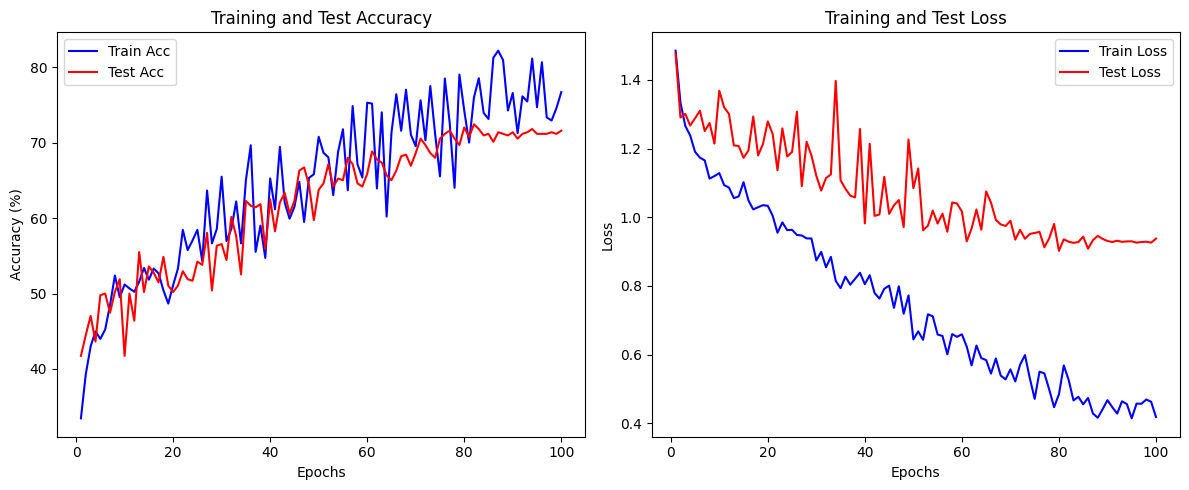

In [5]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler

CFG = {
    "seed": 42,
    "epochs": 100,
    "max_lr": 2e-3,
    "weight_decay": 0.01,
    "batch_size": 64,
    "mixup_alpha": 0.1
}

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def mixup_data(x, y, alpha=0.1):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).cuda()
    return lam * x + (1 - lam) * x[index, :], y, y[index], lam

def plot_history(history):
    epochs = range(1, len(history["train_acc"]) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Đồ thị Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_acc"], 'b', label='Train Acc')
    plt.plot(epochs, history["test_acc"], 'r', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    # Đồ thị Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_loss"], 'b', label='Train Loss')
    plt.plot(epochs, history["test_loss"], 'r', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig("training_history.png") # Lưu file ảnh để xem trên Kaggle
    plt.show()

def train():
    data_root = "/kaggle/input/datasets/dinhthithanhvy/midterm-32-deepland/datasets"
    device = torch.device("cuda")
    set_seed(CFG["seed"])
    
    train_loader, test_loader, class_names = get_dataloaders(data_root)
    model = NetMid(n_class=len(class_names)).to(device)
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05) # Giảm smoothing để kích acc
    optimizer = optim.AdamW(model.parameters(), lr=CFG["max_lr"]/10, weight_decay=CFG["weight_decay"])
    
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=CFG["max_lr"], 
        steps_per_epoch=len(train_loader), 
        epochs=CFG["epochs"],
        pct_start=0.3
    )
    
    scaler = GradScaler("cuda")
    best_acc = 0.0
    
    # Khởi tạo history
    history = {
        "train_loss": [], "train_acc": [],
        "test_loss": [], "test_acc": []
    }

    print(f"🚀 Training with History Tracking | Epochs: {CFG['epochs']}")
    print("-" * 70)

    for epoch in range(1, CFG["epochs"] + 1):
        t0 = time.time()
        
        # --- TRAIN ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for img, lbl in train_loader:
            img, lbl = img.to(device), lbl.to(device)
            
            do_mixup = np.random.random() > 0.5
            if do_mixup:
                img_in, lbl_a, lbl_b, lam = mixup_data(img, lbl, CFG["mixup_alpha"])
            else:
                img_in = img
            
            optimizer.zero_grad()
            with autocast("cuda"):
                outputs = model(img_in)
                if do_mixup:
                    loss = lam * criterion(outputs, lbl_a) + (1 - lam) * criterion(outputs, lbl_b)
                else:
                    loss = criterion(outputs, lbl)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
            train_loss += loss.item() * img.size(0)
            train_correct += outputs.max(1)[1].eq(lbl).sum().item()
            train_total += lbl.size(0)

        # --- EVAL ---
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        with torch.no_grad():
            for img, lbl in test_loader:
                img, lbl = img.to(device), lbl.to(device)
                outputs = model(img)
                loss = criterion(outputs, lbl)
                
                test_loss += loss.item() * img.size(0)
                test_correct += outputs.max(1)[1].eq(lbl).sum().item()
                test_total += lbl.size(0)
        
        # Lưu log vào history
        history["train_loss"].append(train_loss / train_total)
        history["train_acc"].append(100. * train_correct / train_total)
        history["test_loss"].append(test_loss / test_total)
        history["test_acc"].append(100. * test_correct / test_total)
        
        test_acc = history["test_acc"][-1]
        print(f"Epoch [{epoch:3d}] | Train: {history['train_acc'][-1]:5.2f}% | Test: {test_acc:5.2f}% | Time: {time.time()-t0:.1f}s")
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"⭐ [NEW BEST]: {best_acc:.2f}%")

    print("-" * 70)
    print(f"✅ Best Accuracy: {best_acc:.2f}%")
    
    # Vẽ đồ thị sau khi xong
    plot_history(history)

if __name__ == "__main__":
    train()